--- Finding Minimum KLa ---
For F =  6.5 L/h | Required KLa >= 160.0 h^-1 (Min CL = 0.653 mg/L)
For F =  7.5 L/h | Required KLa >=  50.0 h^-1 (Min CL = 4.708 mg/L)
For F =  8.5 L/h | Required KLa >=  50.0 h^-1 (Min CL = 4.836 mg/L)
For F =  9.5 L/h | Required KLa >=  50.0 h^-1 (Min CL = 4.906 mg/L)
For F = 10.0 L/h | Required KLa >=  50.0 h^-1 (Min CL = 4.931 mg/L)


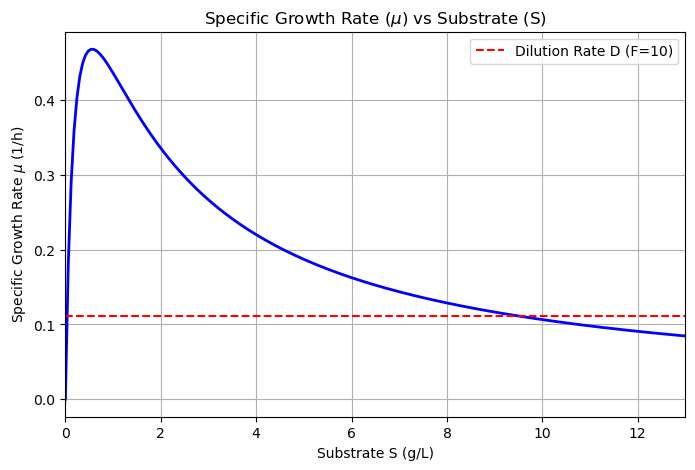

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. Parameter Definitions ---
mu_m = 0.9      # 1/h
Ks = 0.21       # g/L
KI = 1.5        # g/L
Yxs = 0.6       # g/L / g/L
KCL = 0.2       # mg/L
Yos = 160.0     # mg/g
M = 0.0314
VL = 90.0       # L
G = 5000.0      # L/h
eps = 0.2
CLi = 6.0       # mg/L
CGi = 250.0     # mg/L
Si = 30.0       # g/L
VG = eps * VL   # L

# Critical oxygen limit (3 * KCL)
CL_crit = 3 * KCL 

# --- 2. The ODE System ---
def system_of_odes(t, y, F, KLa):
    X, S, CL, CG = y
    
    # Avoid negative values during stiff solving
    X = max(0, X)
    S = max(0, S)
    CL = max(0, CL)
    CG = max(0, CG)
    
    # Intermediary equations
    CL_star = M * CG
    mu = (mu_m * S / (Ks + S + (S**2)/KI)) * (CL / (KCL + CL))
    
    # Mass balances
    dXdt = -(F/VL)*X + mu*X
    dSdt = (F/VL)*(Si - S) - (1/Yxs)*mu*X
    dCLdt = (F/VL)*(CLi - CL) - (Yos/Yxs)*mu*X + KLa*(CL_star - CL)
    dCGdt = (G/VG)*(CGi - CG) - KLa*(VL/VG)*(CL_star - CL)
    
    return [dXdt, dSdt, dCLdt, dCGdt]

# --- 3. Finding KLa for F = 6.5 to 10 L/h ---
F_values = [6.5, 7.5, 8.5, 9.5, 10.0]
y0 = [1.0, 0.0, 6.0, 250.0] # Initial conditions: X, S, CL, CG
t_span = (0, 100)           # Run for 100 hours to ensure steady state

print("--- Finding Minimum KLa ---")
for F in F_values:
    KLa_guess = 50.0 # Start with a baseline guess
    step = 10.0
    
    # Simple search loop to find the minimum safe KLa
    while True:
        sol = solve_ivp(
            system_of_odes, 
            t_span, 
            y0, 
            method='BDF', 
            args=(F, KLa_guess),
            rtol=1e-6, 
            atol=1e-6
        )
        
        min_CL = np.min(sol.y[2])
        
        if min_CL > CL_crit:
            print(f"For F = {F:4.1f} L/h | Required KLa >= {KLa_guess:5.1f} h^-1 (Min CL = {min_CL:.3f} mg/L)")
            break
        else:
            KLa_guess += step

# --- 4. Plotting Growth Kinetics at F = 10 L/h ---
# Assuming CL is maintained at steady state well above limitation (e.g., CL = 2 mg/L)
CL_ss = 2.0 
S_range = np.linspace(0, Si, 500)
mu_range = (mu_m * S_range / (Ks + S_range + (S_range**2)/KI)) * (CL_ss / (KCL + CL_ss))

plt.figure(figsize=(8, 5))
plt.plot(S_range, mu_range, 'b-', linewidth=2)
plt.axhline(y=(10.0/VL), color='r', linestyle='--', label=f'Dilution Rate D (F=10)')
plt.title('Specific Growth Rate ($\mu$) vs Substrate (S)')
plt.xlabel('Substrate S (g/L)')
plt.ylabel('Specific Growth Rate $\mu$ (1/h)')
plt.xlim(0, 13) # Zoom in to see the peak
plt.grid(True)
plt.legend()
plt.show()

--- Running Batch Simulation (F = 0) ---


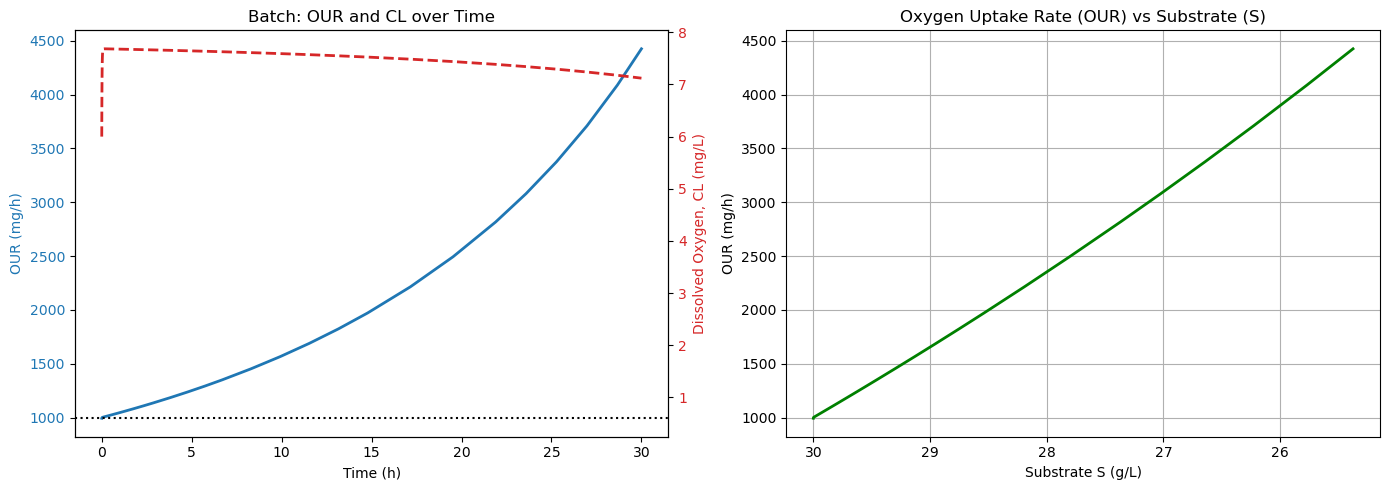

In [4]:
# --- Assuming parameters and `system_of_odes` from Part (a) are already defined ---

print("--- Running Batch Simulation (F = 0) ---")

# 1. Define Batch-Specific Conditions
F_batch = 0.0
KLa_batch = 70.0
t_span_batch = (0, 30)
y0_batch = [1.0, 30.0, 6.0, 250.0] # X(0)=1, S(0)=30, CL(0)=6, CG(0)=250

# 2. Run Simulation (Reusing the exact same ODE function)
sol_batch = solve_ivp(
    system_of_odes, 
    t_span_batch, 
    y0_batch, 
    method='BDF', 
    args=(F_batch, KLa_batch), # Pass F=0 to trigger batch mode
    rtol=1e-6, 
    atol=1e-6
)

t = sol_batch.t
X, S, CL, CG = sol_batch.y

# 3. Calculate OUR (Vectorized for optimization)
# Clean arrays to prevent negative values from stiff solver step-overs
S_cl = np.maximum(0, S)
CL_cl = np.maximum(0, CL)
X_cl = np.maximum(0, X)

# Calculate mu for the whole array at once
mu_batch = (mu_m * S_cl / (Ks + S_cl + (S_cl**2)/KI)) * (CL_cl / (KCL + CL_cl))
mu_batch[S_cl == 0] = 0.0 # Ensure no growth if substrate is exactly 0

OUR = (Yos/Yxs) * mu_batch * X_cl * VL

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: OUR and CL over time
color = 'tab:blue'
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('OUR (mg/h)', color=color)
ax1.plot(t, OUR, color=color, linewidth=2, label='OUR')
ax1.tick_params(axis='y', labelcolor=color)

ax1_sub = ax1.twinx()  
color = 'tab:red'
ax1_sub.set_ylabel('Dissolved Oxygen, CL (mg/L)', color=color)  
ax1_sub.plot(t, CL, color=color, linewidth=2, linestyle='--', label='CL')
ax1_sub.tick_params(axis='y', labelcolor=color)
ax1_sub.axhline(y=0.6, color='k', linestyle=':', label='Oxygen Limit (0.6)')
ax1.set_title('Batch: OUR and CL over Time')

# Plot B: OUR vs Substrate
ax2.plot(S, OUR, 'g-', linewidth=2)
ax2.set_title('Oxygen Uptake Rate (OUR) vs Substrate (S)')
ax2.set_xlabel('Substrate S (g/L)')
ax2.set_ylabel('OUR (mg/h)')
ax2.invert_xaxis() # Read right-to-left as S depletes
ax2.grid(True)

plt.tight_layout()
plt.show()

--- Calculating Gas-Measured OUR ---


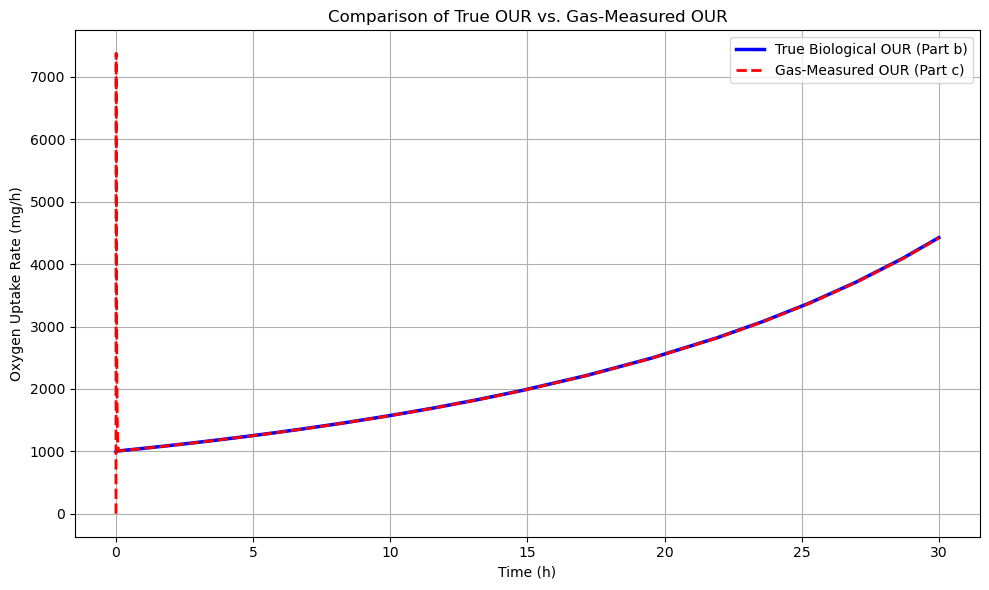

In [5]:
# --- 5. Part (c): Gas-Phase OUR Measurement ---
print("--- Calculating Gas-Measured OUR ---")

# Calculate OUR from the difference between inlet and outlet gas concentrations
# Formula: OUR_gas = Flow Rate (G) * (Inlet CG - Outlet CG)
OUR_gas = G * (CGi - CG)

# --- Plotting the Comparison ---
plt.figure(figsize=(10, 6))

# Plot True Biological OUR (from part b)
plt.plot(t, OUR, 'b-', linewidth=2.5, label='True Biological OUR (Part b)')

# Plot Gas-Measured OUR (from part c)
plt.plot(t, OUR_gas, 'r--', linewidth=2, label='Gas-Measured OUR (Part c)')

plt.title('Comparison of True OUR vs. Gas-Measured OUR')
plt.xlabel('Time (h)')
plt.ylabel('Oxygen Uptake Rate (mg/h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Simulating CSTR with Si = 30 g/L...
Simulating CSTR with Si = 100 g/L...


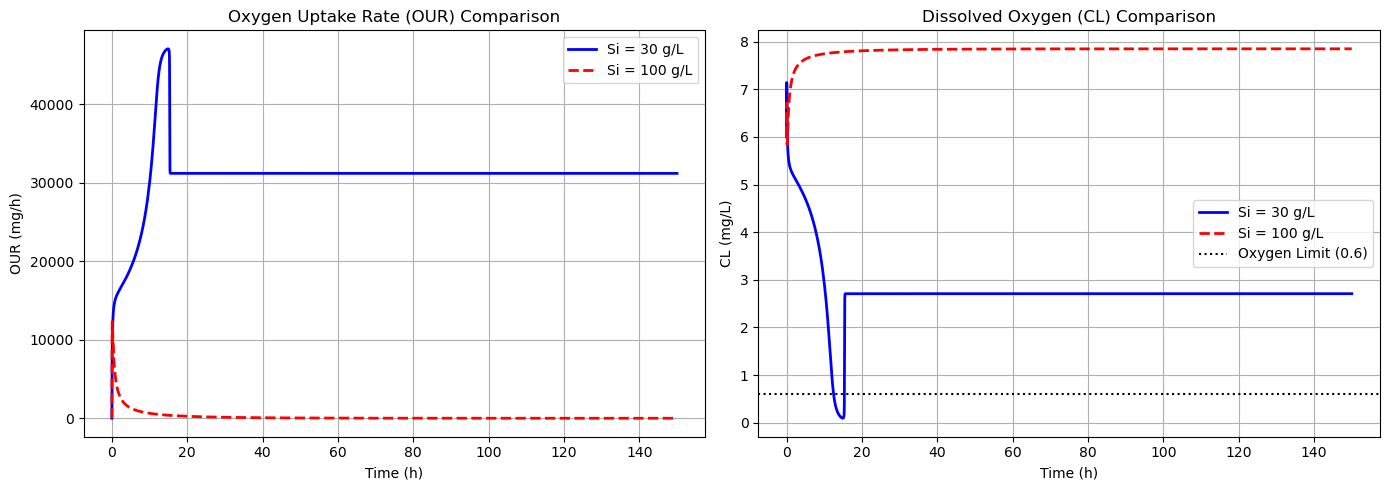

In [6]:
# CSTR specific parameters for this run
F = 6.5        # L/h
KLa = 70.0     # 1/h
t_span = (0, 150)  # Run longer (150h) to ensure steady state is reached
y0 = [1.0, 0.0, 6.0, 250.0]  # Initial S is now 0 in the tank

# --- 2. Updated ODE System (accepts Si as argument) ---
def cstr_odes(t, y, F, KLa, Si):
    X, S, CL, CG = np.maximum(0, y) # Prevent negative values
    
    CL_star = M * CG
    
    if S > 0:
        mu = (mu_m * S / (Ks + S + (S**2)/KI)) * (CL / (KCL + CL))
    else:
        mu = 0.0
        
    dXdt = -(F/VL)*X + mu*X
    dSdt = (F/VL)*(Si - S) - (1/Yxs)*mu*X
    dCLdt = (F/VL)*(CLi - CL) - (Yos/Yxs)*mu*X + KLa*(CL_star - CL)
    dCGdt = (G/VG)*(CGi - CG) - KLa*(VL/VG)*(CL_star - CL)
    
    return [dXdt, dSdt, dCLdt, dCGdt]

# --- 3. Run Simulations ---
print("Simulating CSTR with Si = 30 g/L...")
sol_30 = solve_ivp(cstr_odes, t_span, y0, method='BDF', args=(F, KLa, 30.0), rtol=1e-6, atol=1e-6)

print("Simulating CSTR with Si = 100 g/L...")
sol_100 = solve_ivp(cstr_odes, t_span, y0, method='BDF', args=(F, KLa, 100.0), rtol=1e-6, atol=1e-6)

# --- 4. Calculate OUR for both runs ---
def calculate_our(sol):
    X, S, CL = np.maximum(0, sol.y[0]), np.maximum(0, sol.y[1]), np.maximum(0, sol.y[2])
    mu = (mu_m * S / (Ks + S + (S**2)/KI)) * (CL / (KCL + CL))
    mu[S == 0] = 0.0
    return (Yos/Yxs) * mu * X * VL

OUR_30 = calculate_our(sol_30)
OUR_100 = calculate_our(sol_100)

# --- 5. Plotting Comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# OUR Plot
ax1.plot(sol_30.t, OUR_30, 'b-', linewidth=2, label='Si = 30 g/L')
ax1.plot(sol_100.t, OUR_100, 'r--', linewidth=2, label='Si = 100 g/L')
ax1.set_title('Oxygen Uptake Rate (OUR) Comparison')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('OUR (mg/h)')
ax1.legend()
ax1.grid(True)

# CL Plot
ax2.plot(sol_30.t, sol_30.y[2], 'b-', linewidth=2, label='Si = 30 g/L')
ax2.plot(sol_100.t, sol_100.y[2], 'r--', linewidth=2, label='Si = 100 g/L')
ax2.axhline(y=0.6, color='k', linestyle=':', label='Oxygen Limit (0.6)')
ax2.set_title('Dissolved Oxygen (CL) Comparison')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('CL (mg/L)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()